# EXPLORATORY DATA ANALYSIS
## Does the length of a movie influence its success?
## Tables Used
- **title.basics**: Contains core metadata for titles, including movies, TV shows, and episodes. It provides information such as title type, primary title, release year, runtime, and genres.
- **title.ratings**: Stores user-generated ratings and vote counts for each title. It reflects audience perception and is commonly used as a proxy for popularity and quality.

## Objective

This analysis investigates the relationship between movie runtime and audience ratings to determine whether film length is a statistically meaningful driver of viewer satisfaction.
Specifically, the analysis seeks to establish whether longer productions command higher perceived quality, or whether an optimal runtime range exists that maximises audience reception. The findings aim to provide data-driven guidance for production and post-production decision-making — particularly around pacing, editorial strategy, and final cut duration.

## Target Audience
This analysis is intended for filmmakers, producers, and content strategists involved in production planning and creative decision-making.
By quantifying the impact of runtime on audience satisfaction, this study delivers actionable insight to inform editorial and structural decisions — helping stakeholders balance creative vision with the runtimes most likely to drive strong audience engagement and critical reception.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

## 1. Iinitial dataset investigation
### 1.1. Datasets loading and initial null values removal

In [60]:
basics = pd.read_csv("title.basics.tsv", sep="\t")
ratings = pd.read_csv("title.ratings.tsv", sep="\t")

In [61]:
basics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


In [62]:
ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2201
1,tt0000002,5.5,312
2,tt0000003,6.4,2314
3,tt0000004,5.1,197
4,tt0000005,6.2,3039


> First look through all the tables, we can see there are quite a few missing values as the '\N' placeholder. Therefore, in order to properly look through all the missingness, the '\N' are to be replaced with actuall null values

In [63]:
for df in [basics, ratings]:
    df.replace('\\N', np.nan, inplace=True)

basics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,NaN,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,NaN,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,NaN,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,NaN,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,NaN,1,Short


In [64]:
for df in [basics, ratings]:
    df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12418169 entries, 0 to 12418168
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   tconst          object
 1   titleType       object
 2   primaryTitle    object
 3   originalTitle   object
 4   isAdult         int64 
 5   startYear       object
 6   endYear         object
 7   runtimeMinutes  object
 8   genres          object
dtypes: int64(1), object(8)
memory usage: 852.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657607 entries, 0 to 1657606
Data columns (total 3 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   tconst         1657607 non-null  object 
 1   averageRating  1657607 non-null  float64
 2   numVotes       1657607 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 37.9+ MB


### 1.2. Data cleaning for movies table

> Since the main objective of this project is to figure out if a longer runtime makes a movie well-rated on IMDB, we remove all the other types of media available in the datasets

In [65]:
# First we see what other media types are here 
basics['titleType'].value_counts()

titleType
tvEpisode       9589331
short           1123583
movie            742570
video            324154
tvSeries         297460
tvMovie          154483
tvMiniSeries      69369
tvSpecial         57631
videoGame         48620
tvShort           10967
tvPilot               1
Name: count, dtype: int64

In [66]:
# The movies table only contain the titleType movie
movies = basics[basics['titleType']=='movie']

movies.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
8,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,NaN,45,Romance
144,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,NaN,100,"Documentary,News,Sport"
498,tt0000502,movie,Bohemios,Bohemios,0,1905,NaN,100,NaN
570,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,NaN,70,"Action,Adventure,Biography"
587,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907,NaN,90,Drama


In [67]:
# The movie endYear, titleType and originalTitle is uneccessary in this case, therefore, we drop the variable
movies.drop(columns=['endYear', 'titleType', 'originalTitle'], inplace=True)

# The data types for the other variables need converting as well since that could reduce its interpretibility in later steps
## startYear and runtimeMinutes are obviously numbers so we have to convert them
movies['startYear'] = pd.to_numeric(movies['startYear'], errors='coerce')
movies['runtimeMinutes'] = pd.to_numeric(movies['runtimeMinutes'], errors='coerce')

## isAdult values are 0 and 1, meaning it is a boolean value
movies['isAdult'] = movies['isAdult'].astype('bool')

movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 742570 entries, 8 to 12418119
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          742570 non-null  object 
 1   primaryTitle    742567 non-null  object 
 2   isAdult         742570 non-null  bool   
 3   startYear       631385 non-null  float64
 4   runtimeMinutes  468323 non-null  float64
 5   genres          664765 non-null  object 
dtypes: bool(1), float64(2), object(3)
memory usage: 34.7+ MB


In [68]:
# The percentage of missing values in each column in movies table
movies.isnull().sum() / len(movies) * 100

tconst             0.000000
primaryTitle       0.000404
isAdult            0.000000
startYear         14.972999
runtimeMinutes    36.932141
genres            10.477800
dtype: float64

Missing values in key variables such as `runtime`, `genre`, and release `year` were removed, as these fields are essential for the analysis and cannot be reliably imputed due to their high variability and categorical nature. Although this reduced the dataset size, the remaining sample remains large enough to ensure robust and meaningful results.

In [69]:
movies.dropna(subset=['primaryTitle', 'runtimeMinutes', 'startYear', 'genres'], inplace=True)

movies.isnull().sum()

tconst            0
primaryTitle      0
isAdult           0
startYear         0
runtimeMinutes    0
genres            0
dtype: int64

In [70]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 434070 entries, 8 to 12418119
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          434070 non-null  object 
 1   primaryTitle    434070 non-null  object 
 2   isAdult         434070 non-null  bool   
 3   startYear       434070 non-null  float64
 4   runtimeMinutes  434070 non-null  float64
 5   genres          434070 non-null  object 
dtypes: bool(1), float64(2), object(3)
memory usage: 20.3+ MB


### 1.3. Data cleaning for `genres`
>As seen above, the genres column stores multiple genres as a single comma-separated string — for example, a film may be tagged as "Horror,Drama,Romance". To analyse genres individually, this field was split so that each genre is treated as a separate entry, meaning one film can contribute to multiple genre counts.

In [71]:
all_genres = set(','.join(movies['genres']).split(','))
len(all_genres)

27

In [72]:
from collections import Counter

genre_counts = Counter(
    genre
    for row in movies['genres']
    for genre in row.split(',')
)

genre_counts

Counter({'Drama': 186728,
         'Documentary': 108053,
         'Comedy': 92013,
         'Romance': 40637,
         'Action': 38024,
         'Crime': 32779,
         'Thriller': 31349,
         'Horror': 28413,
         'Adventure': 22876,
         'Mystery': 15478,
         'Biography': 15189,
         'Family': 15156,
         'History': 12924,
         'Music': 12651,
         'Fantasy': 11927,
         'Sci-Fi': 9056,
         'Musical': 8084,
         'War': 7797,
         'Animation': 7656,
         'Sport': 6292,
         'Western': 6245,
         'Adult': 6063,
         'News': 1357,
         'Film-Noir': 875,
         'Reality-TV': 280,
         'Talk-Show': 99,
         'Game-Show': 6})

> From the distribution above, genres with fewer than 1,000 entries — specifically Film-Noir, Reality-TV, Talk-Show, and Game-Show — were removed from the analysis, as such a small sample would produce unreliable and unrepresentative results.

In [73]:
invalid_genres = {'Film-Noir', 'Reality-TV', 'Talk-Show', 'Game-Show', 'News', 'Adult'}

# Remove invalid genres from each row's genre string
movies['genres'] = movies['genres'].apply(
    lambda x: ','.join([g for g in x.split(',') if g not in invalid_genres])
)

# Remove any rows that are now left with no valid genres
movies = movies[movies['genres'] != '']

In [74]:
from collections import Counter

genre_counts = Counter(
    genre
    for row in movies['genres']
    for genre in row.split(',')
)

genre_counts

Counter({'Drama': 186728,
         'Documentary': 108053,
         'Comedy': 92013,
         'Romance': 40637,
         'Action': 38024,
         'Crime': 32779,
         'Thriller': 31349,
         'Horror': 28413,
         'Adventure': 22876,
         'Mystery': 15478,
         'Biography': 15189,
         'Family': 15156,
         'History': 12924,
         'Music': 12651,
         'Fantasy': 11927,
         'Sci-Fi': 9056,
         'Musical': 8084,
         'War': 7797,
         'Animation': 7656,
         'Sport': 6292,
         'Western': 6245})

With low-frequency genres removed, the dataset was examined to understand how many genres are associated with each film.

In [75]:
num_genres = movies['genres'].str.count(',') + 1
num_genres.value_counts()

genres
1    236803
2    106614
3     86432
Name: count, dtype: int64

> As each movie is associated with a maximum of three genres, the level of overlap remains manageable and does not significantly complicate the analysis.

### 1.4. ratings tables

In [76]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657607 entries, 0 to 1657606
Data columns (total 3 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   tconst         1657607 non-null  object 
 1   averageRating  1657607 non-null  float64
 2   numVotes       1657607 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 37.9+ MB


In [77]:
ratings.isnull().sum()

tconst           0
averageRating    0
numVotes         0
dtype: int64


> This table does not seem to contain any missing values, and it would be more informational if it was merged with movies so that we can achieve our objective

To ensure meaningful analysis, only movies with available audience ratings and vote counts were retained. This allows the study to focus on movies with sufficient audience engagement, ensuring that both perceived quality and length can be evaluated reliably.

In [78]:
movies = pd.merge(movies, ratings, on='tconst', how='inner')

movies.head()

,tconst,primaryTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,Miss Jerry,False,1894.0,45.0,Romance,5.3,236
1,tt0000147,The Corbett-Fitzsimmons Fight,False,1897.0,100.0,"Documentary,Sport",5.3,600
2,tt0000574,The Story of the Kelly Gang,False,1906.0,70.0,"Action,Adventure,Biography",6.0,1067
3,tt0000591,The Prodigal Son,False,1907.0,90.0,Drama,5.0,39
4,tt0000679,The Fairylogue and Radio-Plays,False,1908.0,120.0,"Adventure,Fantasy",5.0,85


In [79]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299311 entries, 0 to 299310
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          299311 non-null  object 
 1   primaryTitle    299311 non-null  object 
 2   isAdult         299311 non-null  bool   
 3   startYear       299311 non-null  float64
 4   runtimeMinutes  299311 non-null  float64
 5   genres          299311 non-null  object 
 6   averageRating   299311 non-null  float64
 7   numVotes        299311 non-null  int64  
dtypes: bool(1), float64(3), int64(1), object(3)
memory usage: 16.3+ MB


From the merged dataset, only variables relevant to the analysis objective were retained. The goal of this study is to examine the optimal runtime of a movie based on its quality and popularity.

The following features were kept:

* **`primaryTitle`**: Retained for interpretability and identification of movies in analysis outputs.
* **`startYear`**: Enables temporal context and allows for potential trend-based analysis.
* **`runtimeMinutes`**: Included as a structural attribute of films, which may influence audience reception.
* **`genres`**: A key variable for this study, used to analyse whether different genres exhibit consistent or polarising rating patterns.
* **`averageRating`**: The primary outcome variable representing audience evaluation.
* **`numVotes`**: Serves as a proxy for popularity and reliability of ratings.


The following features were removed:

* **titleType, originalTitle**: Redundant or not relevant to the analysis after filtering to movies.

This feature selection step ensures that the dataset remains focused, interpretable, and aligned with the analytical objective while reducing unnecessary complexity.


In [80]:
movies.drop(columns=['tconst', 'isAdult'], inplace=True)

# We rename the columns to make sure that it's easier to understand and in the same format
movies.rename(columns={
    'primaryTitle': 'title',
    'startYear': 'year',
    'runtimeMinutes': 'runtime',
    'averageRating': 'avg_rating',
    'numVotes': 'num_votes'
}, inplace=True)

movies.head()

,title,year,runtime,genres,avg_rating,num_votes
0,Miss Jerry,1894.0,45.0,Romance,5.3,236
1,The Corbett-Fitzsimmons Fight,1897.0,100.0,"Documentary,Sport",5.3,600
2,The Story of the Kelly Gang,1906.0,70.0,"Action,Adventure,Biography",6.0,1067
3,The Prodigal Son,1907.0,90.0,Drama,5.0,39
4,The Fairylogue and Radio-Plays,1908.0,120.0,"Adventure,Fantasy",5.0,85


> We perform one last check for missingness in the final dataset

In [81]:
(movies.isnull().sum() / len(movies)) * 100

title         0.0
year          0.0
runtime       0.0
genres        0.0
avg_rating    0.0
num_votes     0.0
dtype: float64

> With missing values addressed and irrelevant variables removed, the dataset is now clean and well-structured. We can proceed with a thorough inspection of the remaining variables to better understand the distribution and characteristics of the data.

---
## 2. Data Inspection
In this step, we take a closer look at the dataset and its overall distributions to understand the general characteristics of the data. 

This includes examining summary statistics — such as the average runtime, the most common rating, and how spread out the values are — to get a sense of what a "typical" film in the dataset looks like. We also look for any unusual values or unexpected patterns that could affect the analysis. This step is important as it ensures we have a solid understanding of the data before drawing any conclusions from it.

### 2.1. Summary statistics

In [82]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299311 entries, 0 to 299310
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   title       299311 non-null  object 
 1   year        299311 non-null  float64
 2   runtime     299311 non-null  float64
 3   genres      299311 non-null  object 
 4   avg_rating  299311 non-null  float64
 5   num_votes   299311 non-null  int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 13.7+ MB


In [83]:
movies.describe()

,year,runtime,avg_rating,num_votes
count,299311.000000,299311.000000,299311.000000,2.993110e+05
mean,1997.734246,94.650922,6.147632,4.221251e+03
std,26.069933,140.398247,1.348763,4.031942e+04
min,1894.000000,1.000000,1.000000,5.000000e+00
25%,1982.000000,81.000000,5.300000,2.500000e+01
50%,2008.000000,91.000000,6.300000,8.600000e+01
75%,2018.000000,104.000000,7.100000,4.240000e+02
max,2026.000000,51420.000000,10.000000,3.175485e+06


The table above provides a high-level overview of the numerical variables in the dataset. Below are the key takeaways:

`Year`: Films in the dataset span from as early as 1894 to 2026, with the average film released around 1997. However, the majority of films fall between 1982 and 2018, suggesting the dataset is weighted towards more modern productions.

`Runtime`: The average film runs approximately 95 minutes, which aligns with typical industry standards. However, the maximum value of 51,420 minutes is a clear outlier and does not represent a realistic film length — this will need to be addressed before analysis.

`Rating`: Ratings range from 1.0 to 10.0, with an average of 6.1 and a median of 6.3, suggesting the distribution is fairly balanced without a strong skew in either direction. This indicates that most films in the dataset are perceived as average to above average by audiences.

`Number of Votes`: The average number of votes per film is approximately 4,190, however the maximum of over 3 million indicates the presence of extremely popular films that could skew the analysis. The median of 85 votes suggests that the majority of films have relatively modest audience engagement.

> From this analysis, we can clearly see outliers in 2 vairables (`runtime` and `num_votes`). In order to correctly analyse the dataset, these outliers must be investigated and removed if appropriate

### 2.2. Outlier detection
### a. num_votes
The number of votes is used as a measure of movie popularity, reflecting the level of audience engagement each film receives.

Given the wide variation in vote counts across movies, the distribution is expected to be highly skewed.

In [84]:
movies['num_votes'].describe()

count    2.993110e+05
mean     4.221251e+03
std      4.031942e+04
min      5.000000e+00
25%      2.500000e+01
50%      8.600000e+01
75%      4.240000e+02
max      3.175485e+06
Name: num_votes, dtype: float64

> The statistical summary highlights a significant imbalance in the distribution of movie popularity. While the average number of votes is approximately 4,200, the maximum exceeds 3.1 million, indicating the presence of a small number of extremely popular films.

This large disparity suggests a highly right-skewed distribution, where most movies receive relatively low levels of audience engagement, and only a few achieve widespread attention. To ensure meaningful interpretation and effective visualisation, a logarithmic transformation is applied. This approach reduces the impact of extreme values and allows patterns across both low- and high-popularity movies to be examined more clearly within a single view.

Text(0.5, 1.0, 'Outliers in Number of votes (Log Scale)')

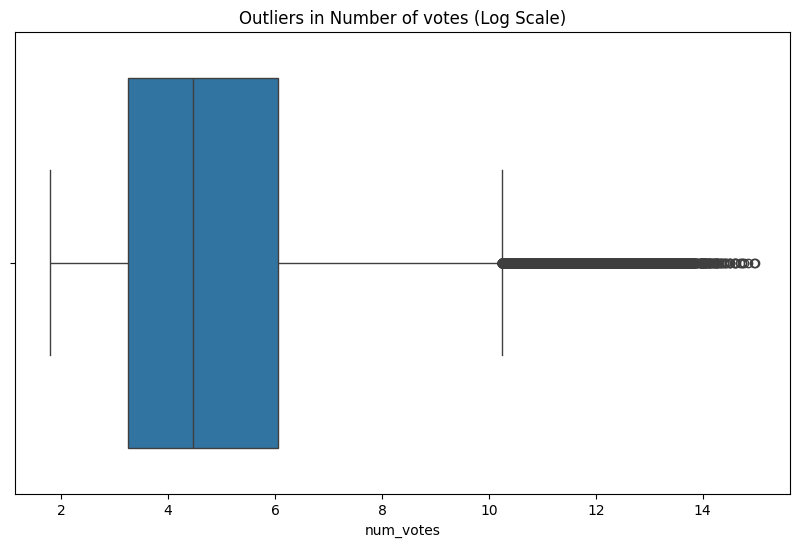

In [85]:
plt.figure(figsize=(10,6))
sns.boxplot(x=np.log1p(movies['num_votes']))
plt.title('Outliers in Number of votes (Log Scale)')

> The distribution shows a small number of movies with exceptionally high vote counts, which appear as statistical outliers. However, these observations represent genuinely popular films rather than data errors. As the objective of this analysis is to understand the relationship between popularity and audience ratings, these high-value observations are essential and have been retained. Instead of removing them, the use of a logarithmic scale ensures that the data can be interpreted effectively without distorting key patterns.

#### b. runtime

In [86]:
movies['runtime'].describe()

count    299311.000000
mean         94.650922
std         140.398247
min           1.000000
25%          81.000000
50%          91.000000
75%         104.000000
max       51420.000000
Name: runtime, dtype: float64

In [87]:
movies['runtime'].value_counts().sort_index()

runtime
1.0        3
3.0        1
5.0        1
7.0        1
14.0       1
          ..
9000.0     1
14400.0    1
28643.0    1
43200.0    1
51420.0    1
Name: count, Length: 407, dtype: int64

> The runtime variable contains both extremely short and excessively long values that are not representative of standard movie formats. 

Very short runtimes likely correspond to short films or non-traditional content, while extremely long runtimes reflect data inconsistencies or non-standard entries. To ensure meaningful analysis, the dataset was restricted to movies within a realistic duration range, which is around 1 to 3 hours, focusing on full-length films.

In [88]:
print(f'Percentage of movies with less than 60 minute runtime: {len(movies[movies['runtime'] < 60]) / len(movies) * 100:.2f}%')
print(f'Percentage of movies with more than 240 minute (4 hours) runtime: {len(movies[movies['runtime'] > 240]) / len(movies) * 100:.2f}%')

Percentage of movies with less than 60 minute runtime: 5.71%
Percentage of movies with more than 240 minute (4 hours) runtime: 0.17%


> The distribution of movie runtime shows that the vast majority of films fall within a standard duration range. Only 5.76% of movies have a runtime below 60 minutes, while just 0.54% exceed 180 minutes (3 hours). This indicates that extremely short and excessively long movies are relatively rare and not representative of typical film formats. As such, the analysis will focus on movies within the 60 to 180 minute range to ensure that insights reflect standard industry practices and audience expectations.

In [89]:
movies = movies[(movies['runtime'] >= 60) & (movies['runtime'] <= 240)]

In [90]:
# movies['runtime'].describe()

#### c. year
While the dataset includes films dating back to 1894, earlier records are limited in number and reflect significantly different production contexts, including shorter runtimes and non-standardised formats.

Text(0.5, 1.0, 'Distribution of Movie Release Years')

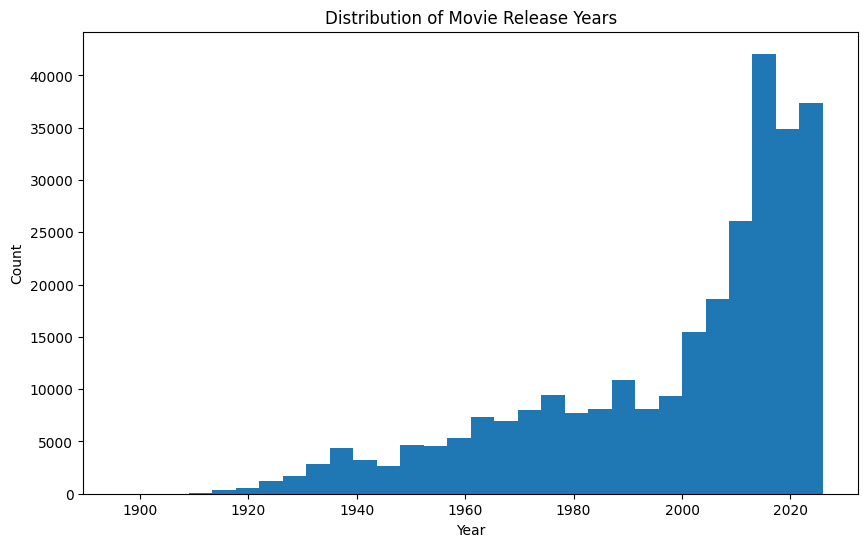

In [91]:
movies['year'].plot.hist(bins=30, figsize=(10,6))
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Distribution of Movie Release Years')

> We can clearly see there are very few movies before 1950 and that year is also considered by many to be the start of modern cinema. So, to ensure meaningful comparisons, the analysis focuses on films released from 1950 onwards, where modern cinematic conventions are more established and data coverage is more consistent.

In [92]:
movies = movies[movies['year'] >= 1950]

### 2.3. Distribution
We create 2 variables for numerical and categorical variables in order to inspect them more easily given their different characteristics.

In [93]:
# List of categorical variables
categorical = [i for i in movies.columns if movies[i].dtypes == 'O']

# List of numerical variables
numerical = [i for i in movies.columns if i not in categorical]

print('categorical:', categorical, '\n', 'numerical: ', numerical)

categorical: ['title', 'genres'] 
 numerical:  ['year', 'runtime', 'avg_rating', 'num_votes']


#### a. Numerical variables

Initial inspection of numerical variables was conducted to understand the overall structure of the dataset.

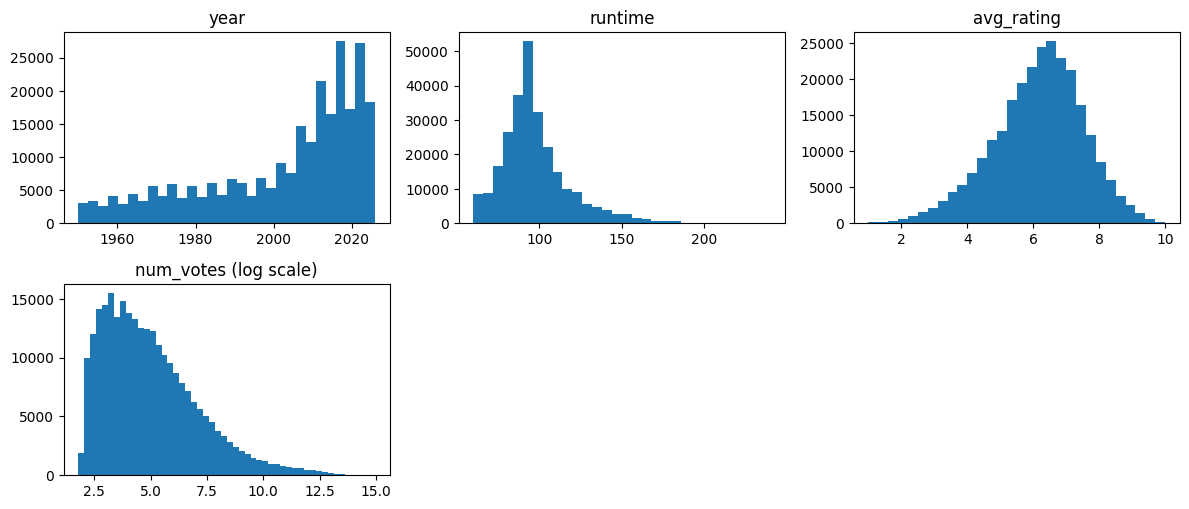

In [94]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(numerical, 1):
    plt.subplot(4, 3, i)
    
    if col == 'num_votes':
        plt.hist(np.log1p(movies[col]), bins=50)
        plt.title(f'{col} (log scale)')
        
    else:
        plt.hist(movies[col], bins=30)
        plt.title(col)

plt.tight_layout()
plt.show()

- **Year**
  - The distribution is skewed towards more recent years, indicating that a large proportion of movies in the dataset are produced in the modern era.
  - This suggests that the analysis is more reflective of contemporary filmmaking practices, which is relevant when interpreting trends such as runtime and audience preferences.

- **Runtime**
  - The distribution is right-skewed, with most movies concentrated between approximately 80 and 110 minutes.
  - This indicates that movie length is relatively standardised, with only a small number of longer films.
  - Given this concentration, variations within this range may have a meaningful impact on audience ratings, making runtime an important variable for identifying a potential optimal duration.

- **Average Rating**
  - Ratings follow a roughly symmetric, bell-shaped distribution, suggesting that most movies receive moderate audience evaluations.
  - Extreme ratings (very high or very low) are relatively uncommon, indicating that differences in rating across runtime groups are likely to be subtle rather than drastic.

- **Number of Votes (Popularity)**
  - The distribution remains skewed even after applying a logarithmic transformation, showing that a small number of movies receive significantly more audience attention than others.
  - This highlights that popularity is unevenly distributed and must be considered when analysing ratings, as highly visible movies may influence observed trends.


#### b. Distribution of Runtime

Text(0.5, 0, 'Runtime (minutes)')

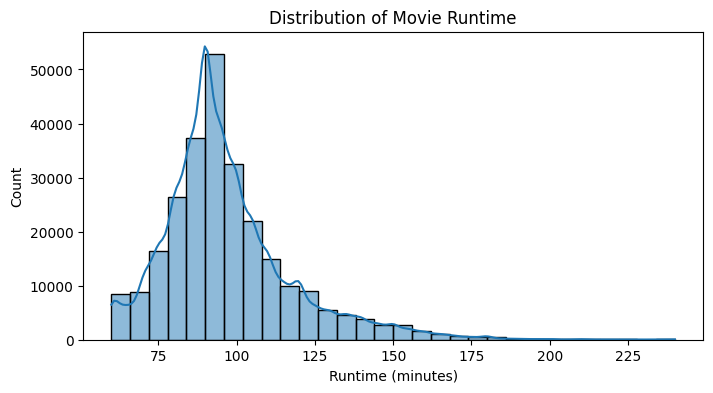

In [95]:
plt.figure(figsize=(8,4))
sns.histplot(movies['runtime'], bins=30, kde=True)
plt.title('Distribution of Movie Runtime')
plt.xlabel('Runtime (minutes)')

The distribution of movie runtime shows that most films are concentrated within a relatively narrow range, typically between 80 and 110 minutes. This indicates that the industry follows a fairly standard approach to movie length, likely reflecting what is considered optimal for audience engagement. The peak around 90 minutes suggests that many films are intentionally structured around this duration, balancing storytelling with viewer attention. As runtime increases beyond this range, the number of movies declines steadily, with only a small proportion exceeding two hours.

> **This pattern suggests that longer movies are less common and may be more selective in nature, potentially representing higher-investment or more ambitious productions.**

Understanding this distribution is important, as it highlights that movie length is not random, but a deliberate decision. This provides a strong foundation to further explore whether certain runtime ranges are associated with better audience ratings, and whether an optimal movie length exists.

#### c. Distribution of Average ratings

In [96]:
movies['avg_rating'].describe()

count    263057.000000
mean          6.111887
std           1.363390
min           1.000000
25%           5.300000
50%           6.200000
75%           7.000000
max          10.000000
Name: avg_rating, dtype: float64

Text(0.5, 0, 'Ratings')

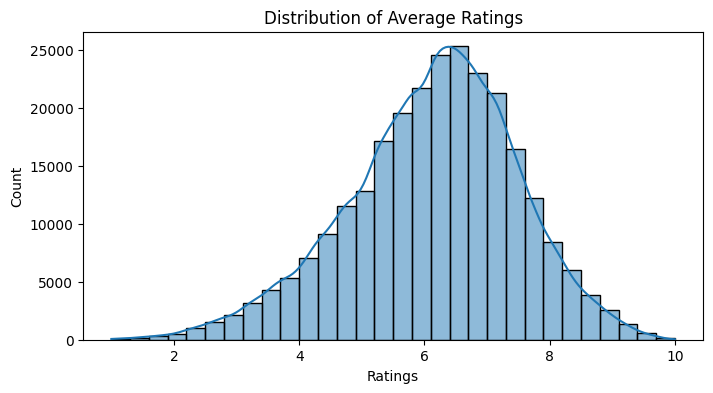

In [97]:
plt.figure(figsize=(8,4))
sns.histplot(movies['avg_rating'], bins=30, kde=True)
plt.title('Distribution of Average Ratings')
plt.xlabel('Ratings')

The distribution of average movie ratings shows that most films fall within a moderate range, typically between 5 and 7. This indicates that audience evaluations are relatively consistent, with the majority of movies achieving similar levels of reception. The peak around the mid-range suggests that films are generally perceived as average to above-average, with fewer movies standing out at the extremes.

As ratings move toward very high or very low values, the number of movies declines, with only a small proportion achieving exceptional audience approval or strong negative reception.

> **This pattern suggests that differences in movie quality, as perceived by audiences, are relatively incremental rather than extreme, making it more challenging for films to significantly outperform others in terms of ratings.**

#### d. Distribution of number of votes

Text(0.5, 0, 'Number of votes (log scaled)')

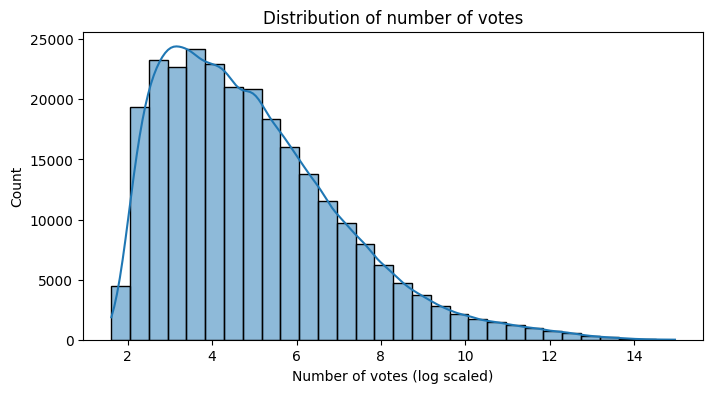

In [98]:
plt.figure(figsize=(8,4))
sns.histplot(np.log(movies['num_votes']), bins=30, kde=True)
plt.title('Distribution of number of votes')
plt.xlabel('Number of votes (log scaled)')

The distribution of the number of votes, even after applying a logarithmic scale, shows that most movies receive relatively low to moderate levels of audience engagement, with only a small number achieving very high visibility. This indicates that audience attention is not evenly distributed, and the majority of films operate within a limited reach.

The peak in the lower-to-mid range suggests that most movies attract a modest number of viewers, while the frequency declines as the number of votes increases, with very few films reaching extremely high levels of engagement.

> **This pattern suggests that a small number of movies dominate audience attention, potentially due to factors such as marketing, franchise recognition, or production scale, rather than purely content quality.**

---
# 3. Data analysis 
## 3.1. Average rating by runtime 
Having examined each variable individually, the next step is to explore how they interact with one another to uncover meaningful relationships.

To ensure clear and interpretable comparisons, runtime was grouped into intervals rather than analysed at an individual level. Given the large volume of data and the relatively small variation in ratings, grouping allows underlying trends to be observed more effectively, while reducing noise from individual observations.

In [99]:
# We divide all runtime into 4 groups 
max_runtime = movies['runtime'].max()
bins = [0, 60, 90, 120, 150, 180, max_runtime + 1]
labels = ['<60', '60-90', '90-120', '120-150', '150-180', '>180'] 

movies['runtime_group'] = pd.cut(movies['runtime'], bins=bins, labels=labels)

Text(0.5, 1.0, 'Count of movies by runtime group')

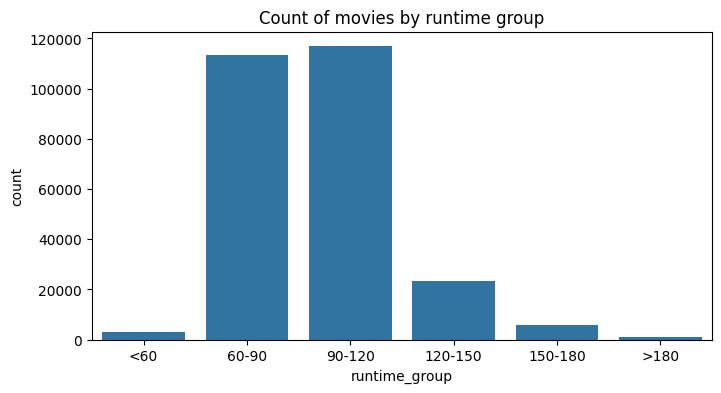

In [100]:
plt.figure(figsize=(8,4))
sns.countplot(x=movies['runtime_group'])
plt.title('Count of movies by runtime group')

> The 60–90 minute group accounts for the majority of movies, with a similarly high concentration in the 90–120 minute range, reinforcing that most films adhere to standard runtime conventions. In contrast, longer movies are relatively rare, suggesting that higher-rated long films may reflect selective production rather than a general advantage of longer runtime.

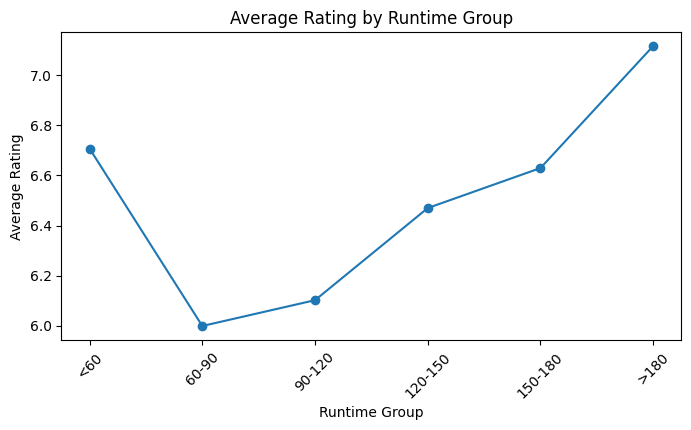

In [138]:
runtime_analysis = movies.groupby('runtime_group', observed=True)['avg_rating'].mean()

plt.figure(figsize=(8,4))
ax = runtime_analysis.plot(marker='o')

plt.title('Average Rating by Runtime Group')
plt.xlabel('Runtime Group')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

plt.show()

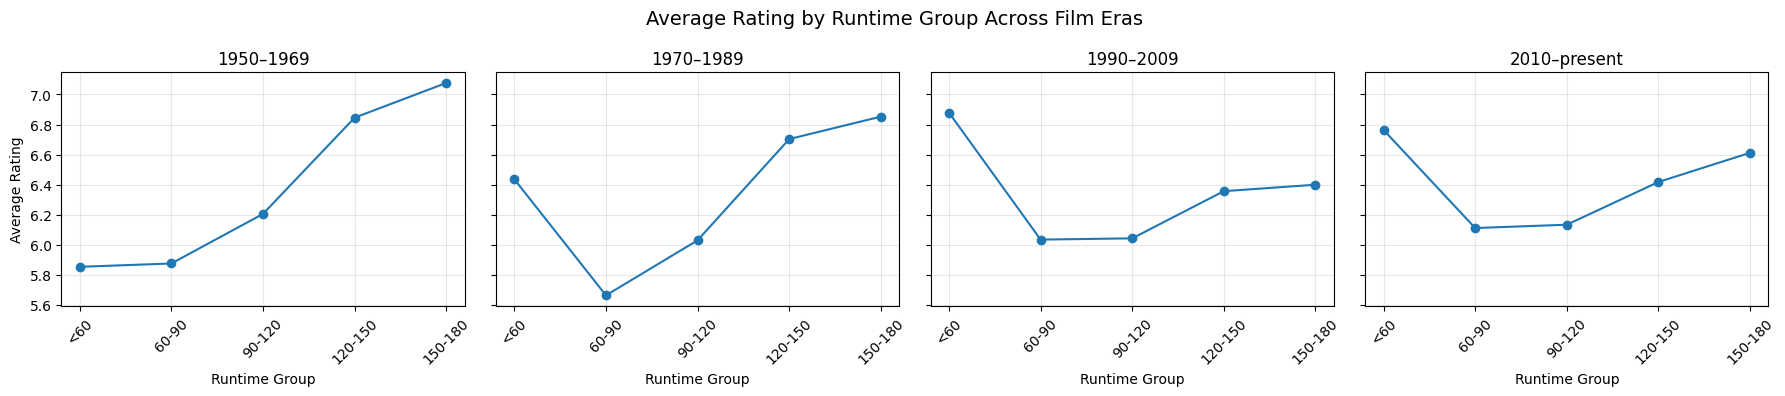

In [155]:
def classify_period(year):
    if year < 1970:
        return '1950–1969'
    elif year < 1990:
        return '1970–1989'
    elif year < 2010:
        return '1990–2009'
    else:
        return '2010–present'

movies['period'] = movies['year'].apply(classify_period)

periods = ['1950–1969', '1970–1989', '1990–2009', '2010–present']

fig, axes = plt.subplots(1, 4, figsize=(18,4), sharey=True)

for i, period in enumerate(periods):
    subset = movies[movies['period'] == period]
    
    runtime_analysis = subset.groupby(
        'runtime_group', observed=True
    )['avg_rating'].mean()
    
    # ensure correct order
    runtime_analysis = runtime_analysis.reindex(
        ['<60','60-90','90-120','120-150','150-180','180+']
    )
    
    ax = axes[i]
    runtime_analysis.plot(marker='o', ax=ax)
    
    ax.set_title(period)
    ax.set_xlabel('Runtime Group')
    
    if i == 0:
        ax.set_ylabel('Average Rating')
    
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

plt.suptitle('Average Rating by Runtime Group Across Film Eras', fontsize=14)
plt.tight_layout()

plt.show()

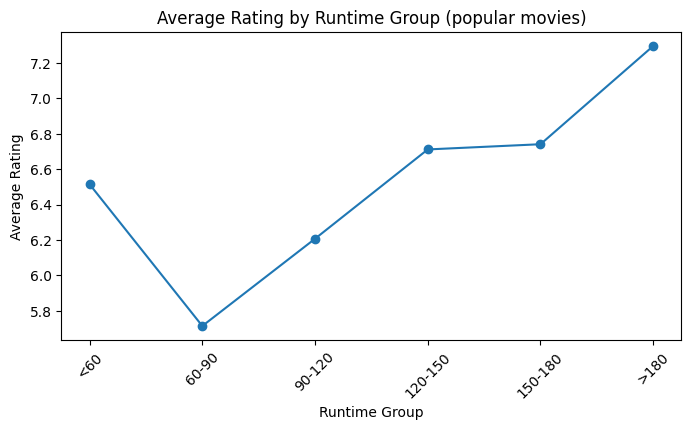

In [153]:
runtime_analysis = popular_movies.groupby('runtime_group', observed=True)['avg_rating'].mean()

plt.figure(figsize=(8,4))
ax = runtime_analysis.plot(marker='o')

plt.title('Average Rating by Runtime Group (popular movies)')
plt.xlabel('Runtime Group')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

plt.show()

> The results show a gradual increase in average ratings as movie runtime increases, with films in the more than 180 minute range achieving the highest average rating of over 6.9. However, the differences between runtime groups are relatively small, indicating that while longer movies tend to perform slightly better, the overall impact of runtime on ratings is limited rather than substantial.

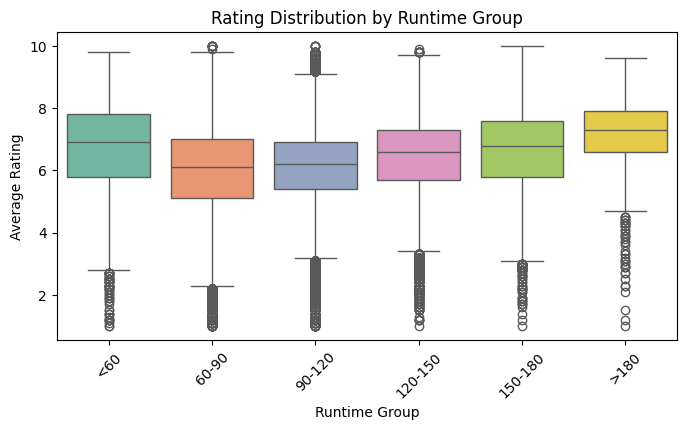

In [102]:
plt.figure(figsize=(8,4))
sns.boxplot(x='runtime_group', y='avg_rating', data=movies, palette='Set2', hue='runtime_group', legend=False)

plt.title('Rating Distribution by Runtime Group')
plt.xlabel('Runtime Group')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

plt.show()

> The boxplot reinforces the observed trend, with median ratings gradually increasing for longer runtime groups. However, the differences are modest, and the significant overlap in distributions suggests that runtime alone does not strongly differentiate movie quality.

**This suggests that although longer movies tend to achieve higher ratings, they represent a much smaller and more selective subset of films. As a result, their higher ratings may reflect stronger production quality, higher investment, or greater audience interest, rather than runtime alone being the primary driver of success.**

## 3.2. Number of votes by runtime group

### a. Average votes across runtime groups (before filter)

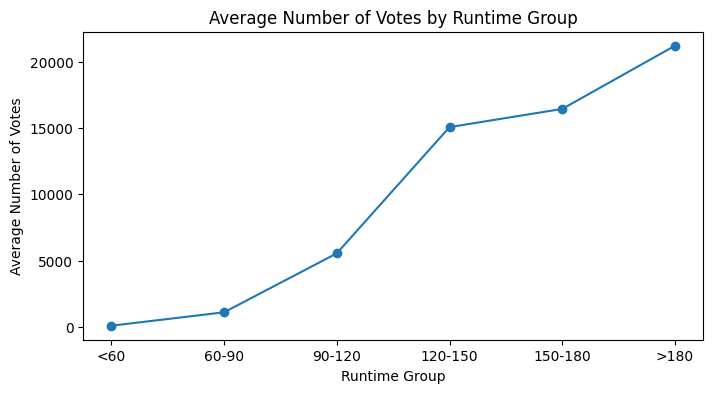

In [103]:
runtime_votes = movies.groupby('runtime_group', observed=True)['num_votes'].mean()

plt.figure(figsize=(8,4))
runtime_votes.plot(marker='o')
plt.title('Average Number of Votes by Runtime Group')
plt.xlabel('Runtime Group')
plt.ylabel('Average Number of Votes')

plt.show()

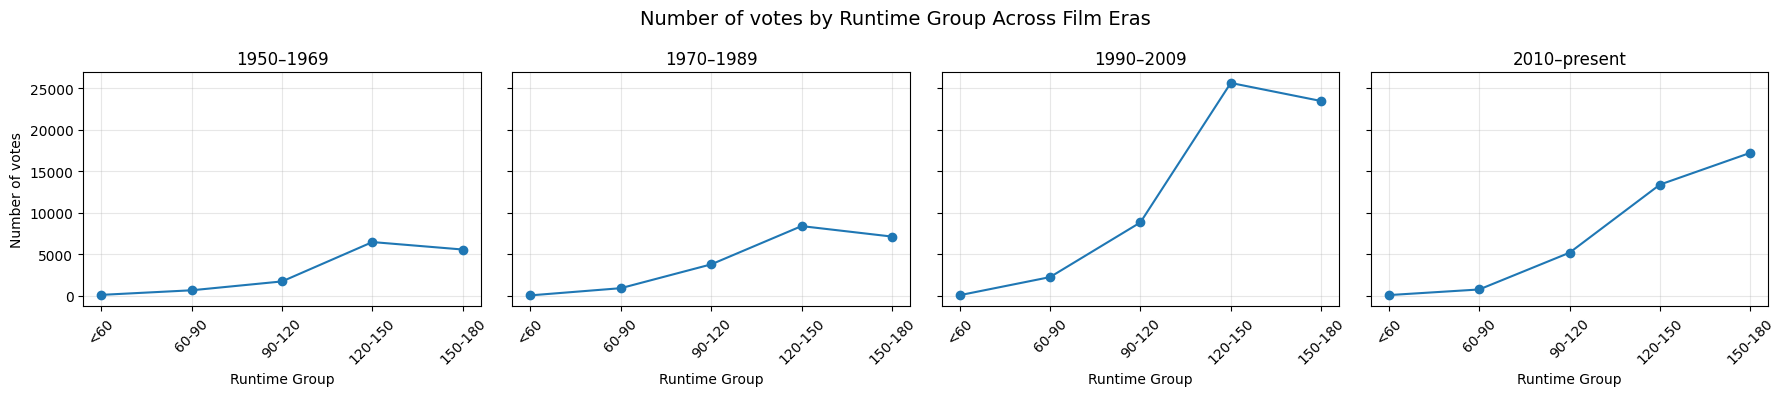

In [159]:
fig, axes = plt.subplots(1, 4, figsize=(18,4), sharey=True)

for i, period in enumerate(periods):
    subset = movies[movies['period'] == period]
    
    runtime_analysis = subset.groupby(
        'runtime_group', observed=True
    )['num_votes'].mean()
    
    # ensure correct order
    runtime_analysis = runtime_analysis.reindex(
        ['<60','60-90','90-120','120-150','150-180','180+']
    )
    
    ax = axes[i]
    runtime_analysis.plot(marker='o', ax=ax)
    
    ax.set_title(period)
    ax.set_xlabel('Runtime Group')
    
    if i == 0:
        ax.set_ylabel('Number of votes')
    
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

plt.suptitle('Number of votes by Runtime Group Across Film Eras', fontsize=14)
plt.tight_layout()

plt.show()

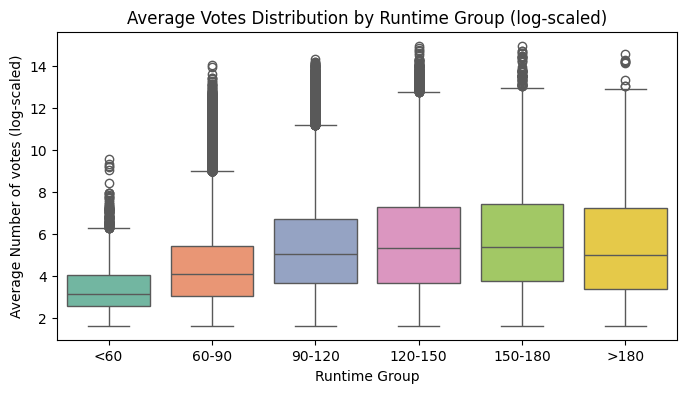

In [104]:
plt.figure(figsize=(8,4))
sns.boxplot(x='runtime_group', y=np.log(movies['num_votes']), data=movies, palette='Set2', hue='runtime_group', legend=False)
plt.title('Average Votes Distribution by Runtime Group (log-scaled)')
plt.xlabel('Runtime Group')
plt.ylabel('Average Number of votes (log-scaled)')
plt.show()

> The most popular group is the 150–180 minute range, with the highest average number of votes, indicating that longer movies tend to attract greater audience engagement.

### b. Average votes across runtime groups (filter applies)
Based on the distribution of votes, a threshold of 1,000 votes was selected to remove low-engagement movies while retaining a sufficiently large and representative sample. Setting a higher threshold (e.g. 10,000 votes) would exclude the majority of the dataset and bias the analysis towards only highly popular films, reducing generalisability.

In [105]:
popular_movies = movies[movies['num_votes'] >= 1000]

In [106]:
print(f'The number of popular movies: {len(popular_movies)}')
print(f'Percentage of popular movie choosen by the threshold: {len(popular_movies) / len(movies) * 100:.2f}%')

The number of popular movies: 45497
Percentage of popular movie choosen by the threshold: 17.30%


Text(0.5, 1.0, 'Count of movies by runtime group (Popular movies)')

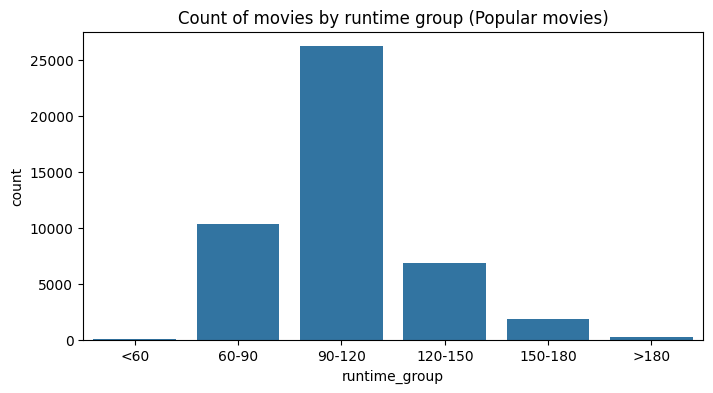

In [107]:
plt.figure(figsize=(8,4))
sns.countplot(x=popular_movies['runtime_group'])
plt.title('Count of movies by runtime group (Popular movies)')

> With popular movies (defined as those with more than 1,000 votes), the majority are concentrated within the 90–120 minute runtime group, followed by the 60–90 minute range. This indicates that even among movies with higher audience engagement, standard runtime lengths continue to dominate, reinforcing the idea that most films are produced within conventional duration ranges.

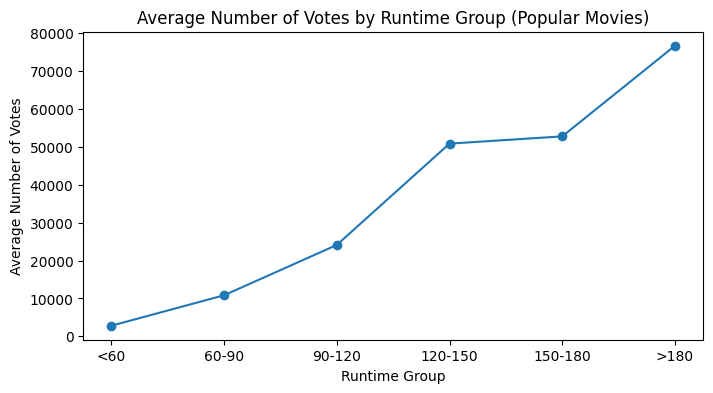

In [141]:
popular_runtime_votes = popular_movies.groupby('runtime_group', observed=True)['num_votes'].mean()

plt.figure(figsize=(8,4))
popular_runtime_votes.plot(marker='o')
plt.title('Average Number of Votes by Runtime Group (Popular Movies)')
plt.xlabel('Runtime Group')
plt.ylabel('Average Number of Votes')

plt.show()

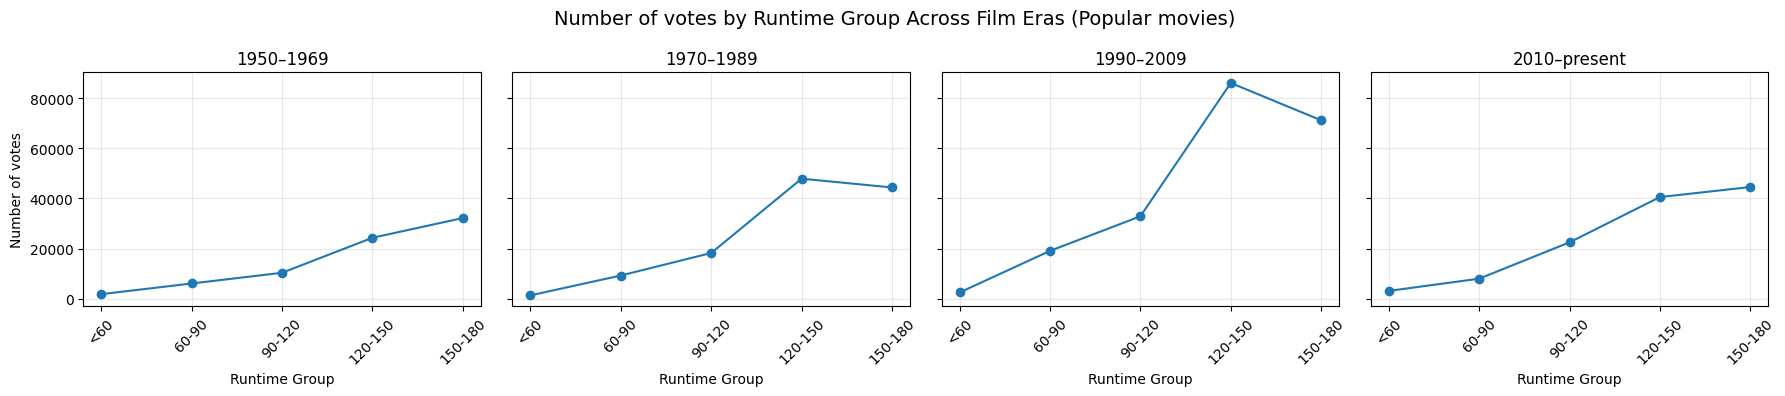

In [160]:

popular_movies['period'] = popular_movies['year'].apply(classify_period)

periods = ['1950–1969', '1970–1989', '1990–2009', '2010–present']

fig, axes = plt.subplots(1, 4, figsize=(18,4), sharey=True)

for i, period in enumerate(periods):
    subset = popular_movies[popular_movies['period'] == period]
    
    runtime_analysis = subset.groupby(
        'runtime_group', observed=True
    )['num_votes'].mean()
    
    # ensure correct order
    runtime_analysis = runtime_analysis.reindex(
        ['<60','60-90','90-120','120-150','150-180','180+']
    )
    
    ax = axes[i]
    runtime_analysis.plot(marker='o', ax=ax)
    
    ax.set_title(period)
    ax.set_xlabel('Runtime Group')
    
    if i == 0:
        ax.set_ylabel('Number of votes')
    
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

plt.suptitle('Number of votes by Runtime Group Across Film Eras (Popular movies)', fontsize=14)
plt.tight_layout()

plt.show()

> Even after filtering for popular movies (those with more than 1,000 votes), the relationship between runtime and popularity remains consistent. This indicates that longer movies are genuinely associated with higher audience attention, rather than the pattern being driven by low-vote or unreliable observations.

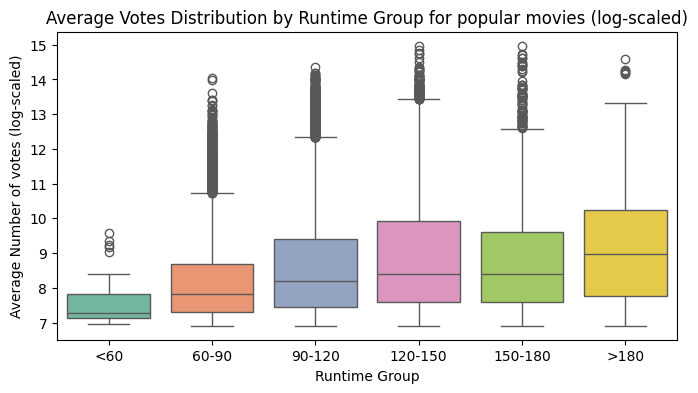

In [109]:
plt.figure(figsize=(8,4))
sns.boxplot(x='runtime_group', y=np.log(popular_movies['num_votes']), data=popular_movies, palette='Set2', hue='runtime_group', legend=False)

plt.title('Average Votes Distribution by Runtime Group for popular movies (log-scaled)')
plt.xlabel('Runtime Group')
plt.ylabel('Average Number of votes (log-scaled)')
plt.show()

> Longer movies tend to receive higher levels of audience engagement, with median vote counts increasing across runtime groups, although the differences are moderate and distributions still overlap.

**The consistency of results after applying the popularity filter indicates that movies in the 150–180 and more than 180 minute group continue to exhibit the highest levels of audience engagement. This provides strong support for the hypothesis that longer movies tend to receive more votes and are therefore more popular.**

Test test
<!-- ## 3.3. Are longer movies rated higher BECAUSE they are more popular?
Since we have found that longer movies are both more popular and has higher ratings, the real question now becomes **"Are longer movies rated higher because they are popular, or do they genuinely reflect higher production quality and audience satisfaction?"** There are 2 possibilities now 
* Runtime does NOT truly affect success but popularity is the real influence
* Runtime has its own effect on success -->

## 3.3. Decade by decade runtime trend
Has the optimal runtime changed over time? Are audiences in the 2010s more or less tolerant of long films than in the 1980s? This adds a temporal dimension to our analysis

In [110]:
# First we create a decade column to see the trend of movies in different decades
movies['decade'] = (movies['year'] // 10) * 10

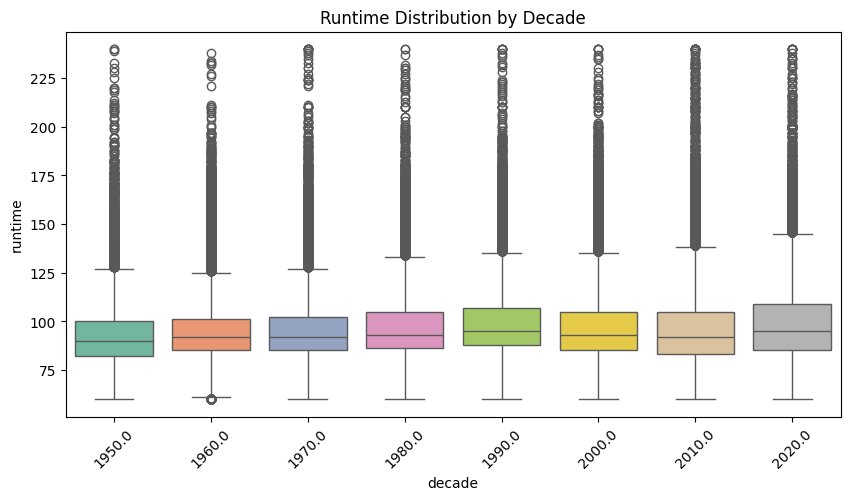

In [111]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='decade',
    y='runtime',
    data=movies,
    palette='Set2',
    hue='decade',
    legend=False
)

plt.xticks(rotation=45)
plt.title('Runtime Distribution by Decade')
plt.show()

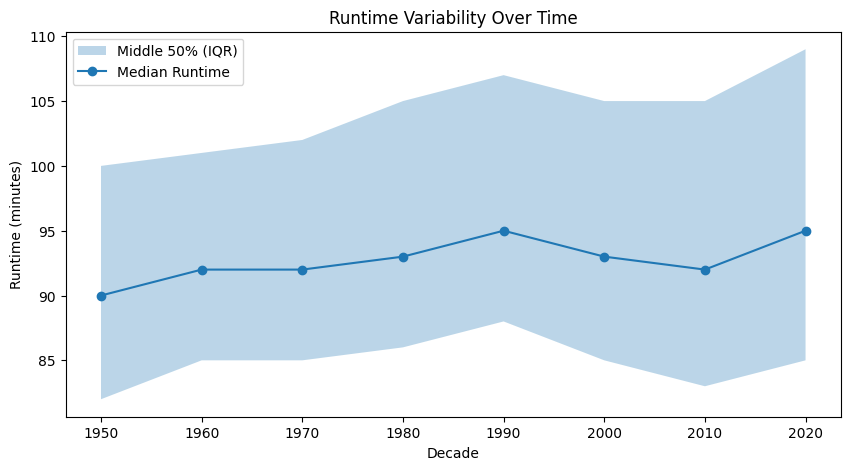

In [112]:
runtime_stats = movies.groupby('decade')['runtime'].agg(
    p25=lambda x: x.quantile(0.25),
    median='median',
    p75=lambda x: x.quantile(0.75)
).reset_index()

plt.figure(figsize=(10,5))

# shaded variability area
plt.fill_between(
    runtime_stats['decade'],
    runtime_stats['p25'],
    runtime_stats['p75'],
    alpha=0.3,
    label='Middle 50% (IQR)'
)

# median line
plt.plot(
    runtime_stats['decade'],
    runtime_stats['median'],
    marker='o',
    label='Median Runtime'
)

plt.title('Runtime Variability Over Time')
plt.xlabel('Decade')
plt.ylabel('Runtime (minutes)')
plt.legend()

plt.show()

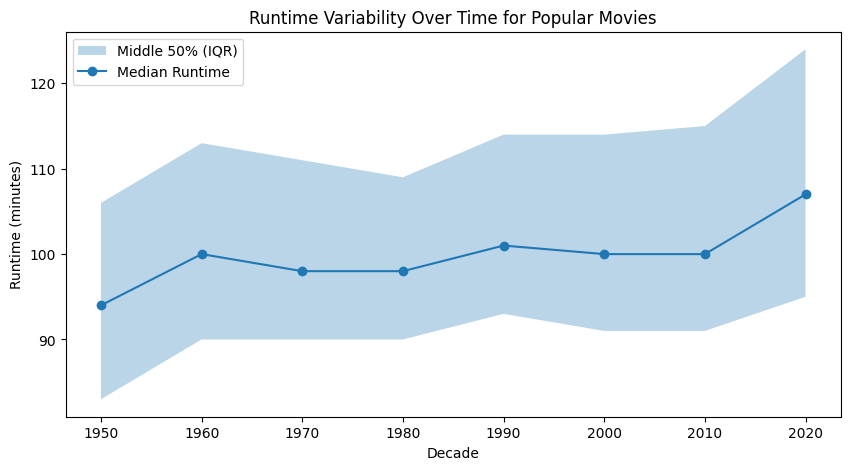

In [146]:
runtime_stats = popular_movies.groupby('decade')['runtime'].agg(
    p25=lambda x: x.quantile(0.25),
    median='median',
    p75=lambda x: x.quantile(0.75)
).reset_index()

plt.figure(figsize=(10,5))

# shaded variability area
plt.fill_between(
    runtime_stats['decade'],
    runtime_stats['p25'],
    runtime_stats['p75'],
    alpha=0.3,
    label='Middle 50% (IQR)'
)

# median line
plt.plot(
    runtime_stats['decade'],
    runtime_stats['median'],
    marker='o',
    label='Median Runtime'
)

plt.title('Runtime Variability Over Time for Popular Movies')
plt.xlabel('Decade')
plt.ylabel('Runtime (minutes)')
plt.legend()

plt.show()

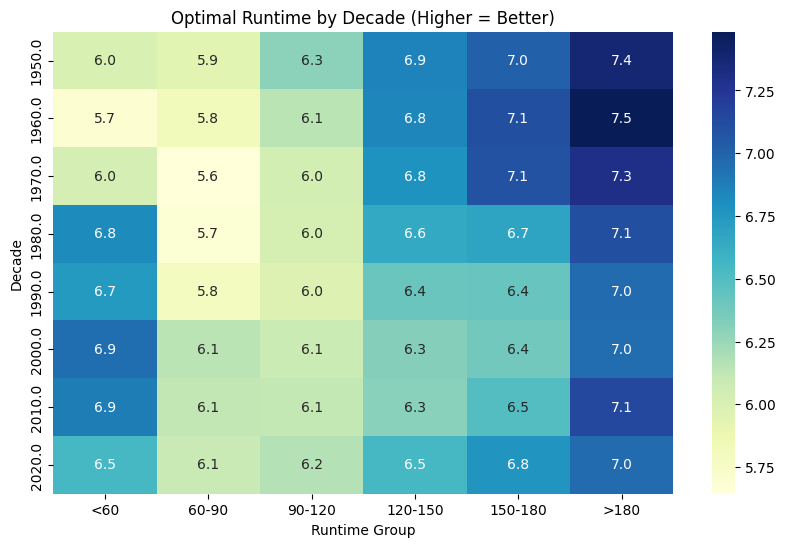

In [136]:
pivot = movies.groupby(
    ['decade', 'runtime_group'],
    observed=True
)['avg_rating'].mean().unstack()

# reorder runtime groups
pivot = pivot[['<60','60-90','90-120','120-150','150-180','>180']]

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")

plt.title('Optimal Runtime by Decade (Higher = Better)')
plt.xlabel('Runtime Group')
plt.ylabel('Decade')

plt.show()

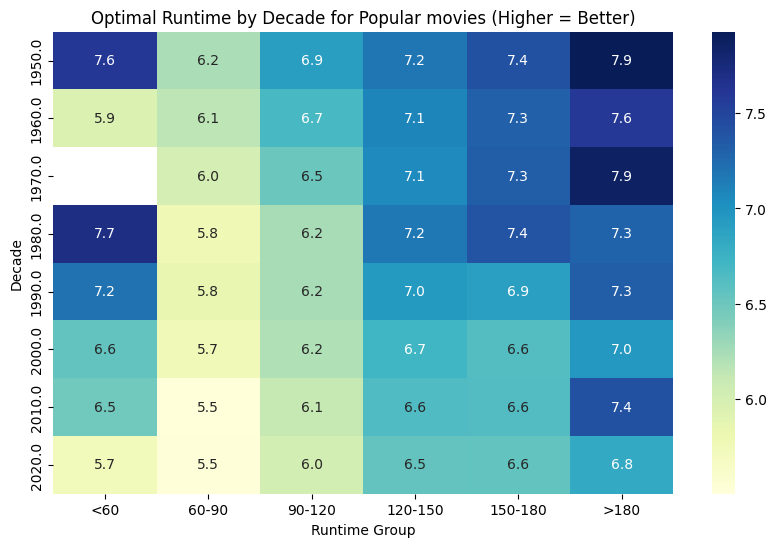

In [147]:
popular_movies['decade'] = (popular_movies['year'] // 10) * 10
pivot = popular_movies.groupby(
    ['decade', 'runtime_group'],
    observed=True
)['avg_rating'].mean().unstack()

# reorder runtime groups
pivot = pivot[['<60','60-90','90-120','120-150','150-180','>180']]

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")

plt.title('Optimal Runtime by Decade for Popular movies (Higher = Better)')
plt.xlabel('Runtime Group')
plt.ylabel('Decade')

plt.show()

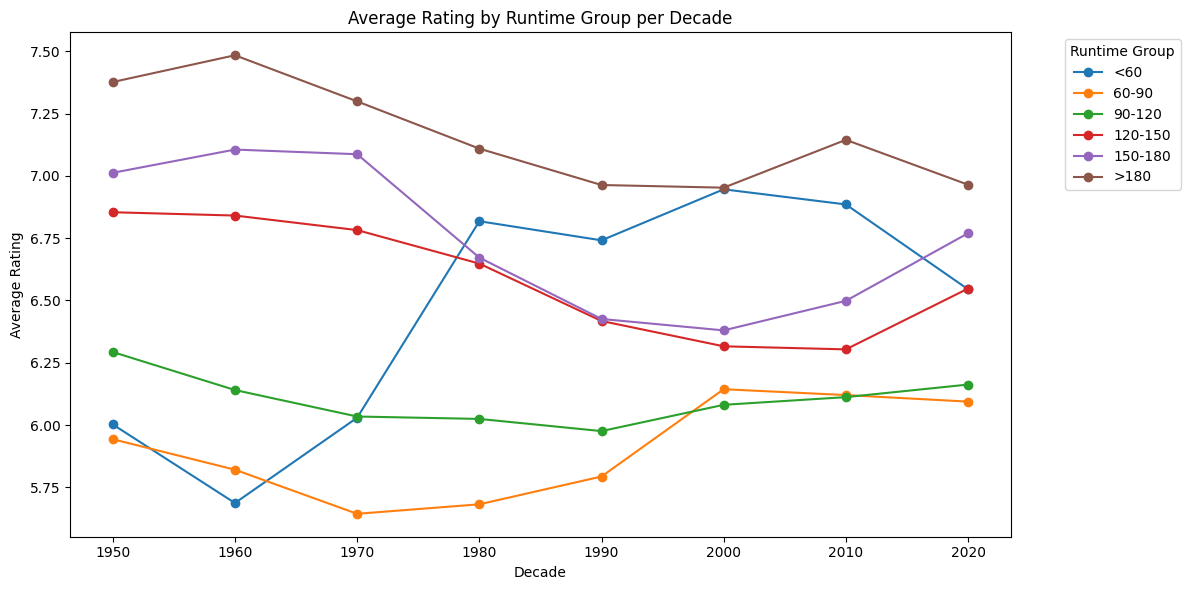

In [137]:
# Get average rating per decade per runtime group
decade_runtime = movies.groupby(['decade', 'runtime_group'])['avg_rating'].mean().reset_index()

# Pivot so runtime groups become columns
decade_pivot = decade_runtime.pivot(index='decade', columns='runtime_group', values='avg_rating')

# Plot
decade_pivot.plot(figsize=(12, 6), marker='o')
plt.title('Average Rating by Runtime Group per Decade')
plt.ylabel('Average Rating')
plt.xlabel('Decade')
plt.legend(title='Runtime Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

> The increasing spread observed in both the boxplots and variability trends suggests that although the average runtime has remained largely unchanged, the range of accepted movie lengths has broadened over time, indicating greater audience tolerance for varied runtimes.

## 3.4. Optimal runtime for each genre

In [113]:
movies_exploded = movies.copy()

# Split
movies_exploded['genres'] = movies_exploded['genres'].str.split(',')
movies_exploded = movies_exploded.explode('genres')

movies_exploded['genres'] = movies_exploded['genres'].str.strip()

# Filter valid genres
valid_genres = [
    'Drama', 'Comedy', 'Documentary', 'Romance',
    'Action', 'Thriller', 'Crime', 'Horror', 'Animation']

movies_genre = movies_exploded[
    movies_exploded['genres'].isin(valid_genres)]

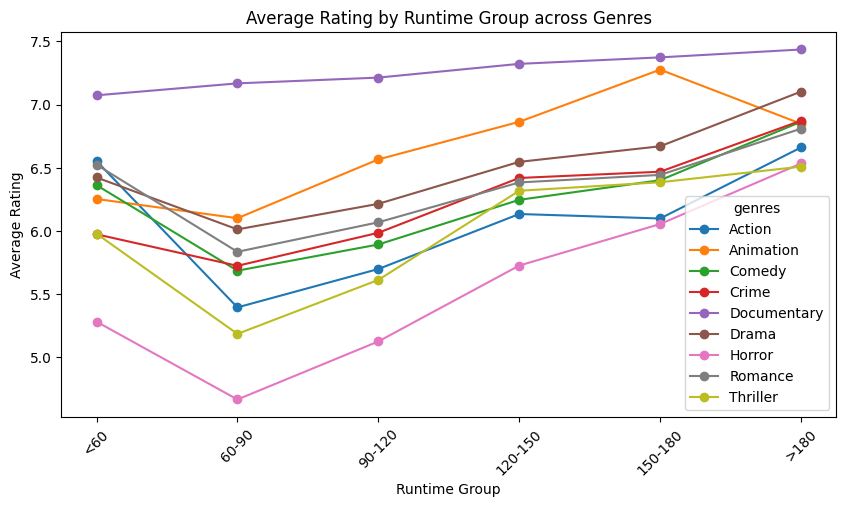

In [114]:
pivot = movies_genre.groupby(
    ['runtime_group', 'genres']
)['avg_rating'].mean().unstack()

pivot.plot(figsize=(10,5), marker='o', legend=True)

plt.title('Average Rating by Runtime Group across Genres')
plt.ylabel('Average Rating')
plt.xlabel('Runtime Group')
plt.xticks(rotation=45)

plt.show()

In [150]:
pop_movies_exploded = popular_movies.copy()

# Split
pop_movies_exploded['genres'] = pop_movies_exploded['genres'].str.split(',')
pop_movies_exploded = pop_movies_exploded.explode('genres')

pop_movies_exploded['genres'] = pop_movies_exploded['genres'].str.strip()

# Filter valid genres
valid_genres = [
    'Drama', 'Comedy', 'Documentary', 'Romance',
    'Action', 'Thriller', 'Crime', 'Horror', 'Animation']

pop_movies_genre= pop_movies_exploded[
    pop_movies_exploded['genres'].isin(valid_genres)]

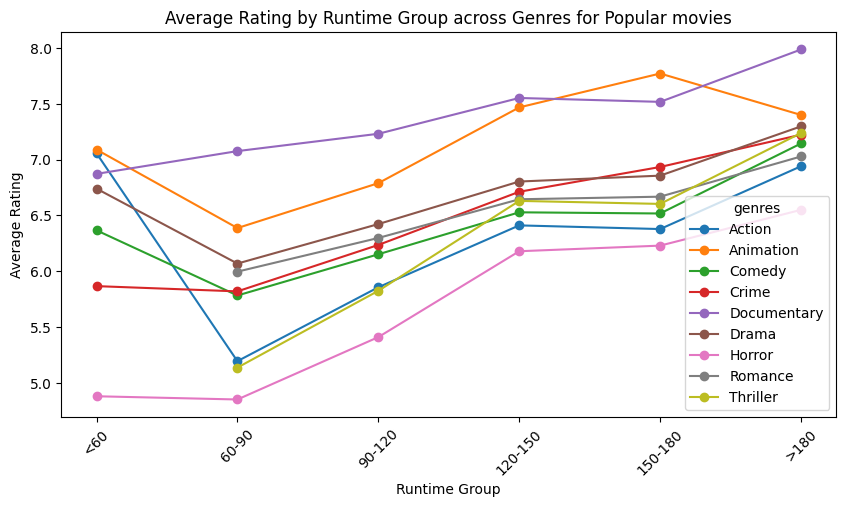

In [154]:
pivot = pop_movies_genre.groupby(
    ['runtime_group', 'genres']
)['avg_rating'].mean().unstack()

pivot.plot(figsize=(10,5), marker='o', legend=True)

plt.title('Average Rating by Runtime Group across Genres for Popular movies')
plt.ylabel('Average Rating')
plt.xlabel('Runtime Group')
plt.xticks(rotation=45)

plt.show()

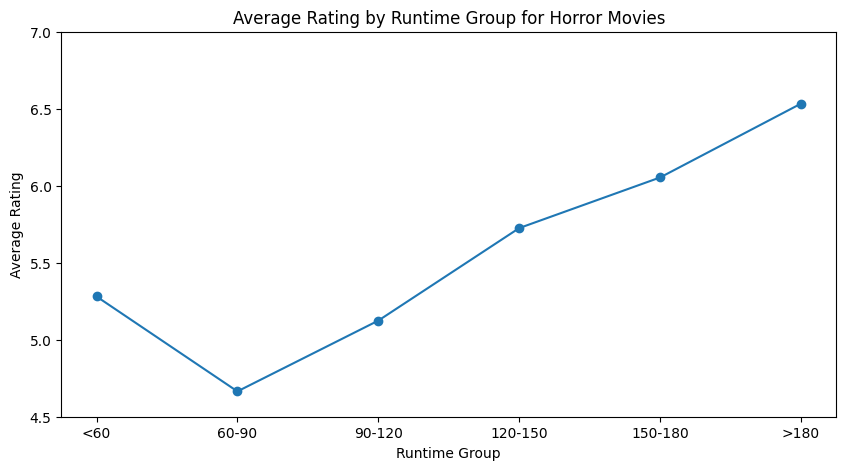

In [126]:
horror = movies_exploded[movies_exploded['genres'] == 'Horror']
horror_pivot = horror.groupby('runtime_group')['avg_rating'].mean()
horror_pivot.plot(figsize=(10, 5), marker='o')
plt.title('Average Rating by Runtime Group for Horror Movies')
plt.ylim(4.5,7)
plt.ylabel('Average Rating')
plt.xlabel('Runtime Group')
plt.show()

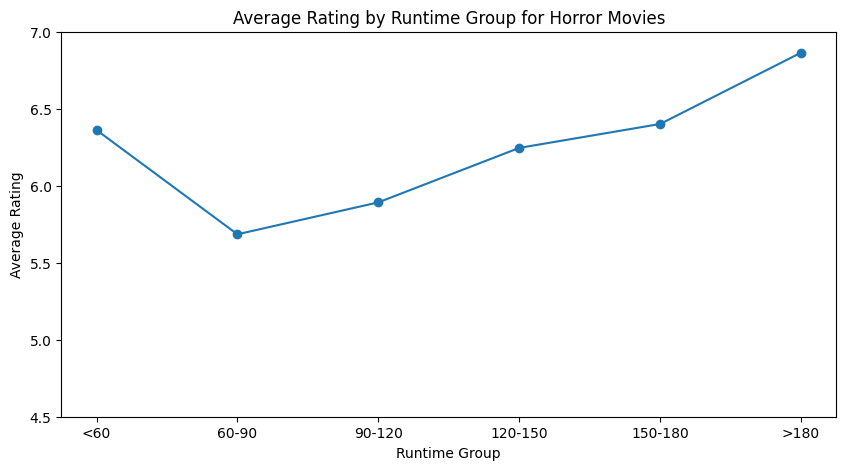

In [125]:
comedy = movies_exploded[movies_exploded['genres'] == 'Comedy']
comedy_pivot = comedy.groupby('runtime_group')['avg_rating'].mean()

comedy_pivot.plot(figsize=(10, 5), marker='o')
plt.title('Average Rating by Runtime Group for Horror Movies')
plt.ylim(4.5,7)
plt.ylabel('Average Rating')
plt.xlabel('Runtime Group')
plt.show()

> Across different genres, there is a difference in how audiences react to each runtime group, with Drama and Documentary benefiting significantly from longer runtimes, whereas Action and Thriller show more limited gains, indicating that pacing rather than duration plays a larger role in these genres.

# 4. Key Insights

**1. Longer Films Consistently Rate Higher**
Across all genres, films in the 150–180 minute and 180+ minute runtime ranges achieve the highest average audience ratings. This suggests that audiences reward films that take time to develop their narrative, characters, and world.

**2. The 60–90 Minute Runtime is the Danger Zone**
Almost every genre experiences its lowest average rating in the 60–90 minute bracket. This is the single most important finding for producers — films in this runtime range are consistently penalised by audiences regardless of genre.

**3. Runtime Sensitivity Varies by Genre**
While longer films rate higher universally, the degree to which runtime impacts ratings differs significantly across genres. Horror and Action are the most sensitive to runtime, suffering the steepest drops at shorter lengths. Comedy and Documentary are relatively stable, suggesting other factors drive their reception more than length alone.

## Actionable Recommendations

| Genre | Avoid | Target |
|-------|-------|--------|
| Action | 60–90 mins | 180+ mins |
| Horror | 60–90 mins | 150–180 mins |
| Drama | 60–90 mins | 180+ mins |
| Animation | Under 90 mins | 150–180 mins |
| Comedy | 60–90 mins | 120+ mins |
| Documentary | No strong penalty | 180+ mins |
| Romance | 60–90 mins | 150+ mins |
| Thriller | 60–90 mins | 150+ mins |

## Limitations to Acknowledge
Higher ratings for longer films may reflect budget and production quality rather than runtime alone — big budget films tend to be both longer and better resourced. This analysis measures correlation, not causation, and should be used as one input among many in production decision-making.